# 11 — Apply exact-risk-factor netting

Offset long and short sensitivities only when complete factor keys are identical.

Sharing a risk class or bucket is not enough. Factor name, tenor, curve, location and other prescribed identifiers must match.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

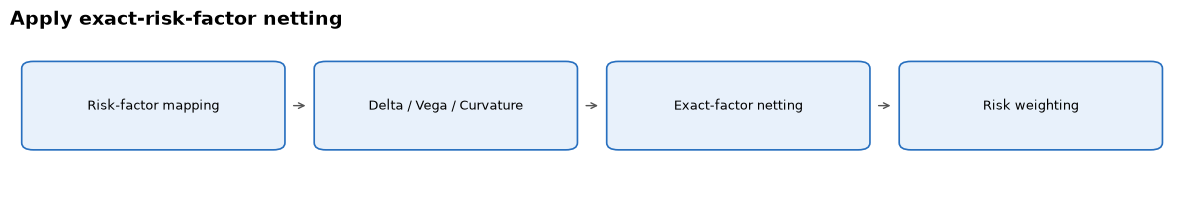

In [2]:
draw_flow(['Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting', 'Risk weighting'],'Apply exact-risk-factor netting',wrap_after=4)

Group trade-level rows by the complete regulatory key and sum their signed sensitivities before applying any risk weight.

$$s_k=\sum_{i\in\text{same exact factor }k}s_{i,k}$$

In [3]:
trade_delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
netted=pd.read_csv(RUN/'06_delta_netted_weighted.csv')
counts=trade_delta.groupby('risk_factor_id').size().sort_values(ascending=False)
factor=counts[counts>1].index[0]
before=trade_delta[trade_delta.risk_factor_id==factor][['trade_id','risk_class','bucket','risk_factor_id','tenor','raw_sensitivity']]
after=netted[netted.risk_factor_id==factor][['risk_class','bucket','risk_factor_id','tenor','raw_sensitivity']]
before['tenor_display']=before.tenor.apply(lambda value:f"{value:g} years" if pd.notna(value) else 'Not applicable for this risk factor')
after['tenor_display']=after.tenor.apply(lambda value:f"{value:g} years" if pd.notna(value) else 'Not applicable for this risk factor')
print(f'Worked exact factor: {factor}')
display(crore_table(before.drop(columns='tenor'),['raw_sensitivity']))
display(crore_table(after.drop(columns='tenor'),['raw_sensitivity']))
print(f"Trade-level signed sum: INR {before.raw_sensitivity.sum():,.2f} per unit change")
print(f"Netted factor sensitivity: INR {after.raw_sensitivity.sum():,.2f} per unit change")

Worked exact factor: USDINR


,trade_id,risk_class,bucket,risk_factor_id,Raw Sensitivity (INR crore per unit change),tenor_display
4,R04,FX,USD,USDINR,17.2911,Not applicable for this risk factor
9,R07,FX,USD,USDINR,0.0000,Not applicable for this risk factor
13,R10,FX,USD,USDINR,1.0027,Not applicable for this risk factor
19,R12,FX,USD,USDINR,0.0330,Not applicable for this risk factor
26,C02,FX,USD,USDINR,12.4621,Not applicable for this risk factor
38,C06,FX,USD,USDINR,-0.0568,Not applicable for this risk factor
41,C07,FX,USD,USDINR,0.0830,Not applicable for this risk factor
49,S01,FX,USD,USDINR,9.7234,Not applicable for this risk factor
52,S02,FX,USD,USDINR,-5.7444,Not applicable for this risk factor
55,T01,FX,USD,USDINR,9.7945,Not applicable for this risk factor


,risk_class,bucket,risk_factor_id,Raw Sensitivity (INR crore per unit change),tenor_display
26,FX,USD,USDINR,84.4465,Not applicable for this risk factor


Trade-level signed sum: INR 844,465,070.98 per unit change
Netted factor sensitivity: INR 844,465,070.98 per unit change


The visual below uses the calculated rows shown above.

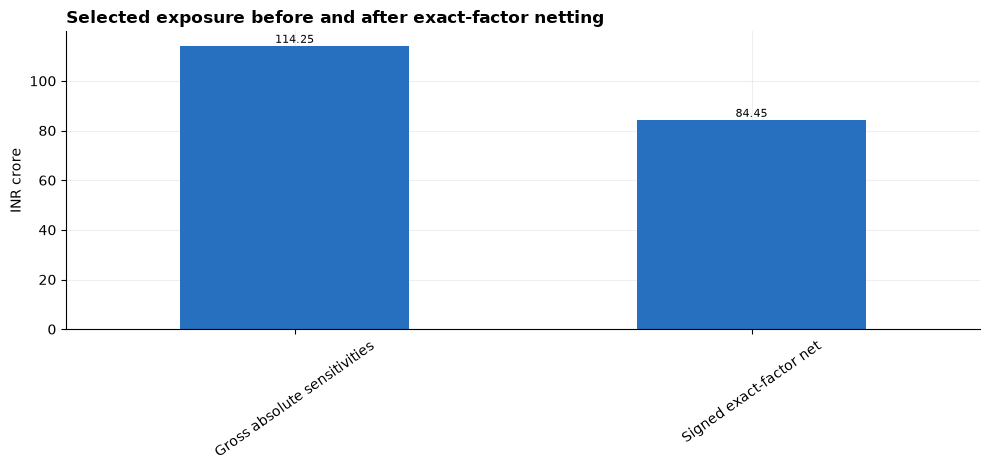

In [4]:
comparison=pd.Series({'Gross absolute sensitivities':before.raw_sensitivity.abs().sum(),
                              'Signed exact-factor net':abs(before.raw_sensitivity.sum())})
bar_crore(comparison,'Selected exposure before and after exact-factor netting')

The result is one net sensitivity per exact regulatory factor.